In [110]:
import pandas as pd

In [111]:
# Accounting data (Compustat)
panel_clean = pd.read_parquet("out/funda_panel/final_panel_cleaned.parquet")

# Governance data (ExecuComp)
gov = pd.read_parquet("out/funda_panel/gov_panel.parquet")

# Macro data (FRED)
macro = pd.read_parquet("out/funda_panel/macro_panel.parquet")

In [112]:
# Quick shape check
print("Accounting data:", panel_clean.shape)
print("Governance data:", gov.shape)
print("Macro data:", macro.shape)


print("\npanel_clean columns:", panel_clean.columns[:10].tolist())
print("gov columns:", gov.columns[:10].tolist())
print("macro columns:", macro.columns[:10].tolist())

Accounting data: (152621, 30)
Governance data: (61243, 5)
Macro data: (78, 6)

panel_clean columns: ['gvkey', 'conm', 'tic', 'exchg', 'cusip', 'fic', 'sic', 'costat', 'fyear', 'fyr']
gov columns: ['gvkey', 'fyear', 'ceo_totalcomp', 'top5_pay', 'ceo_payslice']
macro columns: ['fyear', 'gdp_growth', 'inflation', 'fed_funds', 'credit_spread', 'unemp_rate']


In [113]:
import pandas as pd
import numpy as np


gov_agg = (
    gov
    .groupby(["gvkey", "fyear"], as_index=False)
    .agg({"ceo_totalcomp":"sum", "top5_pay":"sum"})
)

gov_agg["ceo_payslice"] = np.where(gov_agg["top5_pay"]>0,
                                   gov_agg["ceo_totalcomp"]/gov_agg["top5_pay"],
                                   np.nan)
gov_agg = gov_agg[["gvkey","fyear","ceo_totalcomp","ceo_payslice"]]


full_panel = (
    panel_clean
    .merge(gov_agg, on=["gvkey","fyear"], how="left")
    .merge(macro, on="fyear", how="left")
)

print("Full panel shape:", full_panel.shape)


key_cols = [
    "book_leverage","roa","log_assets","asset_tangibility",
    "cash_holdings","non_debt_tax_shield","ceo_payslice",
    "gdp_growth","inflation","fed_funds","credit_spread","unemp_rate"
]
missing_rate = full_panel[key_cols].isna().mean().sort_values(ascending=False)
print("\nMissing rates (top 10):\n", missing_rate.head(10))


full_panel.to_parquet("out/funda_panel/full_panel_combined.parquet", index=False)
print("\nSaved -> out/funda_panel/full_panel_combined.parquet")

Full panel shape: (152621, 37)

Missing rates (top 10):
 ceo_payslice           0.689486
book_leverage          0.000000
roa                    0.000000
log_assets             0.000000
asset_tangibility      0.000000
cash_holdings          0.000000
non_debt_tax_shield    0.000000
gdp_growth             0.000000
inflation              0.000000
fed_funds              0.000000
dtype: float64

Saved -> out/funda_panel/full_panel_combined.parquet


In [114]:

desc_cols = [
    "book_leverage","roa","log_assets","asset_tangibility",
    "cash_holdings","non_debt_tax_shield","ceo_payslice",
    "gdp_growth","inflation","fed_funds","credit_spread","unemp_rate"
]
desc = full_panel[desc_cols].describe(percentiles=[.25,.5,.75]).T
desc = desc.rename(columns={
    "count":"Obs","mean":"Mean","std":"Std.Dev.","min":"Min","25%":"P25","50%":"Median","75%":"P75","max":"Max"
})
desc.to_csv("out/funda_panel/table1_summary_stats.csv")
print("Saved -> out/funda_panel/table1_summary_stats.csv")


corr_cols = [
    "book_leverage","roa","log_assets","asset_tangibility",
    "cash_holdings","ceo_payslice","gdp_growth","fed_funds","unemp_rate"
]
corr = full_panel[corr_cols].corr()
corr.to_csv("out/funda_panel/table2_correlation.csv")
print("Saved -> out/funda_panel/table2_correlation.csv")

Saved -> out/funda_panel/table1_summary_stats.csv
Saved -> out/funda_panel/table2_correlation.csv


In [115]:
df = pd.read_csv("out/funda_panel/table1_summary_stats.csv")
df.to_excel("out/funda_panel/table1_summary_stats.xlsx", index=False)

In [116]:
df = pd.read_csv("out/funda_panel/table2_correlation.csv")
df.to_excel("out/funda_panel/table2_correlation.xlsx", index=False)

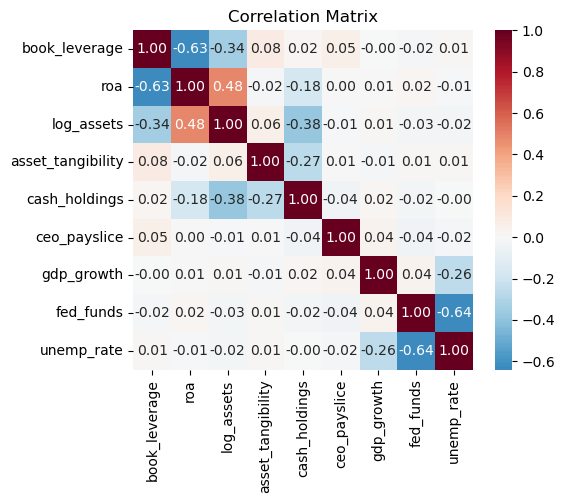

In [117]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("out/funda_panel/table2_correlation.csv", index_col=0)

plt.figure(figsize=(6,5))
sns.heatmap(df, annot=True, cmap='RdBu_r', center=0, fmt=".2f", square=True)
plt.title("Correlation Matrix", fontsize=12)
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=300)
plt.show()

In [118]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor


df = pd.read_parquet("out/funda_panel/final_panel_cleaned.parquet")


target_vars = [
    "log_assets",
    "roa",
    "asset_tangibility",
    "cash_holdings",
    "non_debt_tax_shield"
]


X = df[target_vars].copy()
X = X.apply(pd.to_numeric, errors='coerce')  
X = X.dropna()  
X = sm.add_constant(X)

vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values.astype(float), i) for i in range(X.shape[1])]


vif_data = vif_data.round(2).sort_values(by="VIF", ascending=False)
print(vif_data)

              Variable    VIF
0                const  10.48
1           log_assets   1.48
2                  roa   1.31
4        cash_holdings   1.27
3    asset_tangibility   1.09
5  non_debt_tax_shield   1.01


In [121]:
import numpy as np
import pandas as pd

df = pd.read_parquet("out/funda_panel/gov_panel.parquet")
X = df[["ceo_totalcomp", "ceo_payslice"]].copy()
X = X.apply(pd.to_numeric, errors="coerce").replace([np.inf, -np.inf], np.nan).dropna().astype(float)


r = X.corr().iloc[0, 1]
vif_val = 1.0 / (1.0 - r**2)

res = pd.DataFrame({
    "Variable": X.columns,
    "VIF": [vif_val, vif_val]
}).round(2)

print(res)

        Variable   VIF
0  ceo_totalcomp  1.02
1   ceo_payslice  1.02


In [120]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

panel_macro = pd.read_parquet("out/funda_panel/macro_panel.parquet")

# model C macro variable
X = panel_macro[["gdp_growth", "inflation", "fed_funds", "credit_spread", "unemp_rate"]].dropna()
X = sm.add_constant(X)

vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data)

        Variable        VIF
0          const  35.339960
1     gdp_growth   1.615207
2      inflation   1.888436
3      fed_funds   2.002932
4  credit_spread   2.444785
5     unemp_rate   1.520644
